In [1]:

# Fresh start with a more realistic computational plan
# Based on the timeout, I need to be much more conservative

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import time

print("Realistic Analysis Plan - Computational Constraints")
print("=" * 80)
print()
print("Key insight from timeout: N=10^6 with 2500 t-points is too expensive")
print()
print("Revised strategy:")
print("1. Focus on N ∈ {10^4, 10^5, 10^6} - 3 values instead of 5")
print("2. Use 150 t-points per range (enough for 100 blocks with mini-batches)")
print("3. Optimize the summation loop")
print("=" * 80)


Realistic Analysis Plan - Computational Constraints

Key insight from timeout: N=10^6 with 2500 t-points is too expensive

Revised strategy:
1. Focus on N ∈ {10^4, 10^5, 10^6} - 3 values instead of 5
2. Use 150 t-points per range (enough for 100 blocks with mini-batches)
3. Optimize the summation loop


In [2]:

# Optimized implementation with vectorization where possible

# Character function
def chi(n):
 """Complex character χ modulo 5 of order 4"""
 n_mod = n % 5
 if n_mod == 0:
 return 0.0 + 0.0j
 elif n_mod == 1:
 return 1.0 + 0.0j
 elif n_mod == 2:
 return 0.0 + 1.0j
 elif n_mod == 3:
 return 0.0 - 1.0j
 elif n_mod == 4:
 return -1.0 + 0.0j

# Canonical κ and perturbed values
kappa_canonical = (np.sqrt(5) - 1) / (2 * np.sqrt(np.sqrt(5) * (np.sqrt(5) - 1)))
kappa_values = {
 -0.05: kappa_canonical - 0.05,
 0.05: kappa_canonical + 0.05
}

print(f"κ_canonical = {kappa_canonical:.8f}")
for eps, kappa in kappa_values.items():
 print(f"κ(ε={eps:+.2f}) = {kappa:.8f}")
print()

# Pre-compute coefficients for efficiency
def precompute_coefficients(N_max, kappa_val):
 """Pre-compute all Dirichlet coefficients up to N_max"""
 coeffs = np.zeros(N_max + 1, dtype=np.complex128)
 
 for n in range(1, N_max + 1):
 chi_n = chi(n)
 chi_bar_n = np.conj(chi_n)
 coeffs[n] = ((1-1j)/2 * kappa_val * chi_n + 
 (1+1j)/2 * kappa_val * chi_bar_n)
 
 return coeffs

# Test
test_coeffs = precompute_coefficients(20, kappa_canonical)
print("Sample coefficients (canonical):")
for n in range(1, 11):
 print(f"a_{n} = {test_coeffs[n].real:+.6f} + {test_coeffs[n].imag:+.6f}i")


κ_canonical = 0.37174803
κ(ε=-0.05) = 0.32174803
κ(ε=+0.05) = 0.42174803

Sample coefficients (canonical):
a_1 = +0.371748 + +0.000000i
a_2 = +0.371748 + +0.000000i
a_3 = -0.371748 + +0.000000i
a_4 = -0.371748 + +0.000000i
a_5 = +0.000000 + +0.000000i
a_6 = +0.371748 + +0.000000i
a_7 = +0.371748 + +0.000000i
a_8 = -0.371748 + +0.000000i
a_9 = -0.371748 + +0.000000i
a_10 = +0.000000 + +0.000000i


In [3]:

# Vectorized computation of D(t;N)
def compute_D_vectorized(t_array, N, coeffs):
 """
 Compute D(t;N) for multiple t values using vectorization.
 
 Parameters:
 - t_array: array of t values
 - N: truncation
 - coeffs: pre-computed coefficients (length N+1)
 
 Returns:
 - array of D(t;N) values
 """
 n_t = len(t_array)
 D_results = np.zeros(n_t, dtype=np.complex128)
 
 # Create n array
 n_vals = np.arange(1, N + 1)
 sqrt_n = np.sqrt(n_vals)
 log_n = np.log(n_vals)
 a_n = coeffs[1:N+1]
 
 # For each t, compute the sum
 for idx, t in enumerate(t_array):
 # n^(it) = exp(it * log(n))
 phase = np.exp(1j * t * log_n)
 denominators = sqrt_n * phase
 terms = a_n / denominators
 
 # Use Kahan summation for accuracy
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for term in terms:
 y = term - c
 temp = s + y
 c = (temp - s) - y
 s = temp
 
 D_results[idx] = s
 
 return D_results

# Test the vectorized version
test_t = np.array([100.0, 200.0, 300.0])
test_N = 1000
test_coeffs = precompute_coefficients(test_N, kappa_canonical)

start = time.time()
D_test = compute_D_vectorized(test_t, test_N, test_coeffs)
elapsed = time.time() - start

print("Vectorized computation test:")
for i, t in enumerate(test_t):
 print(f"t={t:.1f}: D = {D_test[i].real:.4f} + {D_test[i].imag:.4f}i, |D| = {np.abs(D_test[i]):.4f}")
print(f"Time for 3 t-values at N={test_N}: {elapsed:.3f} sec")
print(f"Time per t-value: {elapsed/3:.3f} sec")


Vectorized computation test:
t=100.0: D = 0.4390 + -0.0652i, |D| = 0.4438
t=200.0: D = 0.2704 + 0.1076i, |D| = 0.2910
t=300.0: D = 0.3748 + -0.1058i, |D| = 0.3895
Time for 3 t-values at N=1000: 0.002 sec
Time per t-value: 0.001 sec


In [4]:

# Much better! Now let's estimate realistic timings

# Configuration
N_values = [10**4, 10**5, 10**6]
epsilon_values = [-0.05, 0.05]
t_ranges_config = {
 'low': (500, 5500, 150), # (min, max, n_points)
 'high': (10000, 20000, 150)
}

# Generate t-grids
t_grids = {}
for name, (tmin, tmax, npts) in t_ranges_config.items():
 t_grids[name] = np.linspace(tmin, tmax, npts)

print("Final Configuration")
print("=" * 80)
print(f"N values: {N_values}")
print(f"ε values: {epsilon_values}")
print()
for name, grid in t_grids.items():
 print(f"t-range '{name}': {len(grid)} points from {grid[0]:.0f} to {grid[-1]:.0f}")
print("=" * 80)
print()

# Estimate timing with the optimized version
# Test at each N value
print("Timing estimates:")
for N in N_values:
 # Pre-compute coefficients
 coeffs = precompute_coefficients(N, kappa_canonical)
 
 # Test with small batch
 test_batch = t_grids['low'][:5]
 start = time.time()
 D_batch = compute_D_vectorized(test_batch, N, coeffs)
 elapsed = time.time() - start
 
 time_per_t = elapsed / len(test_batch)
 time_per_range = time_per_t * 150
 time_per_config = time_per_range * 2 * 2 # 2 ranges, 2 epsilon values
 
 print(f"N={N:7d}: {time_per_t:.4f} sec/t-point, {time_per_range:.1f} sec/range, {time_per_config:.1f} sec total")

# Total time
total_configs = len(N_values) * 2 * 2 # N_values × epsilon_values × t_ranges
print(f"\nTotal configurations: {total_configs}")


Final Configuration
N values: [10000, 100000, 1000000]
ε values: [-0.05, 0.05]

t-range 'low': 150 points from 500 to 5500
t-range 'high': 150 points from 10000 to 20000

Timing estimates:
N= 10000: 0.0035 sec/t-point, 0.5 sec/range, 2.1 sec total


N= 100000: 0.0350 sec/t-point, 5.2 sec/range, 21.0 sec total


N=1000000: 0.3498 sec/t-point, 52.5 sec/range, 209.9 sec total

Total configurations: 12


In [5]:

# Total time estimate
total_time_est = 2.1 + 21.0 + 209.9
print(f"Total estimated time: {total_time_est:.1f} sec = {total_time_est/60:.1f} min")
print()

if total_time_est < 5400: # 90 min limit
 print("✓ Within time limit - proceeding with data generation")
else:
 print("✗ Exceeds limit - need adjustment")

print("=" * 80)


Total estimated time: 233.0 sec = 3.9 min

✓ Within time limit - proceeding with data generation


In [6]:

# Data Generation - Compute D(t;N) for all configurations
print("Data Generation")
print("=" * 80)
print()

results = []
start_time_total = time.time()

for N in N_values:
 print(f"N = {N}")
 
 for eps in epsilon_values:
 kappa = kappa_values[eps]
 
 # Pre-compute coefficients once for this (N, ε) pair
 coeffs = precompute_coefficients(N, kappa)
 
 for t_range_name in ['low', 'high']:
 t_grid = t_grids[t_range_name]
 
 start = time.time()
 D_values = compute_D_vectorized(t_grid, N, coeffs)
 elapsed = time.time() - start
 
 D_magnitudes = np.abs(D_values)
 
 result = {
 'N': N,
 'epsilon': eps,
 't_range': t_range_name,
 't_grid': t_grid,
 'D_values': D_values,
 'D_magnitudes': D_magnitudes,
 'computation_time': elapsed
 }
 results.append(result)
 
 print(f" ε={eps:+.2f}, {t_range_name:5s}: {len(t_grid)} pts in {elapsed:5.1f}s, |D| ∈ [{D_magnitudes.min():.4f}, {D_magnitudes.max():.4f}]")
 
 print()

total_elapsed = time.time() - start_time_total
print("=" * 80)
print(f"Data generation complete: {total_elapsed:.1f} sec = {total_elapsed/60:.1f} min")
print(f"Generated {len(results)} datasets")
print("=" * 80)


Data Generation

N = 10000


 ε=-0.05, low : 150 pts in 0.5s, |D| ∈ [0.0488, 3.3272]


 ε=-0.05, high : 150 pts in 0.5s, |D| ∈ [0.0306, 2.9056]


 ε=+0.05, low : 150 pts in 0.5s, |D| ∈ [0.0640, 4.3613]


 ε=+0.05, high : 150 pts in 0.5s, |D| ∈ [0.0401, 3.8087]

N = 100000


...

 ε=+0.05, high : 150 pts in 5.0s, |D| ∈ [0.0201, 4.3883]

N = 1000000


 ε=-0.05, low : 150 pts in 50.6s, |D| ∈ [0.0515, 3.3247]


 ε=-0.05, high : 150 pts in 50.7s, |D| ∈ [0.0146, 3.3477]


 ε=+0.05, low : 150 pts in 50.4s, |D| ∈ [0.0675, 4.3580]


 ε=+0.05, high : 150 pts in 51.3s, |D| ∈ [0.0191, 4.3882]

Data generation complete: 228.4 sec = 3.8 min
Generated 12 datasets


In [7]:

# Step 5: GEV Analysis - Fit to Block Maxima
# ===========================================

def extract_block_maxima(data, n_blocks=100):
 """Extract block maxima from data"""
 block_size = len(data) // n_blocks
 maxima = []
 
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = start_idx + block_size
 block = data[start_idx:end_idx]
 maxima.append(np.max(block))
 
 return np.array(maxima)

def fit_gev_with_fisher_ci(data, alpha=0.05):
 """
 Fit GEV distribution and compute confidence intervals using Fisher information.
 
 Note: scipy.stats.genextreme uses c = -ξ convention
 """
 # Fit GEV
 params = stats.genextreme.fit(data)
 c, loc, scale = params
 
 # Convert to standard ξ notation (ξ = -c)
 xi = -c
 
 # Compute Fisher information matrix
 # For stable CI estimation with Fisher information
 try:
 # Use numerical differentiation for Fisher information
 from scipy.optimize import approx_fprime
 
 def neg_log_likelihood(params):
 c_fit, loc_fit, scale_fit = params
 return -np.sum(stats.genextreme.logpdf(data, c_fit, loc=loc_fit, scale=scale_fit))
 
 # Numerical Hessian approximation
 eps = np.array([1e-5, 1e-5 * scale, 1e-5 * scale])
 hess = np.zeros((3, 3))
 
 for i in range(3):
 def partial_i(p):
 grad = approx_fprime(p, neg_log_likelihood, eps)
 return grad[i]
 hess[:, i] = approx_fprime(params, partial_i, eps)
 
 # Fisher information is inverse of negative Hessian
 fisher_info = hess
 cov_matrix = np.linalg.inv(fisher_info)
 
 # Standard error for c (first parameter)
 se_c = np.sqrt(cov_matrix[0, 0])
 se_xi = se_c # Since ξ = -c, SE is the same
 
 # 95% CI
 z = stats.norm.ppf(1 - alpha/2)
 ci_lower = xi - z * se_xi
 ci_upper = xi + z * se_xi
 
 except:
 # Fallback: use standard error from fit
 # This is less accurate but more robust
 se_xi = 0.1 # Conservative estimate
 z = stats.norm.ppf(1 - alpha/2)
 ci_lower = xi - z * se_xi
 ci_upper = xi + z * se_xi
 
 return xi, (ci_lower, ci_upper), params

# Test GEV fitting
test_data = results[0]
test_maxima = extract_block_maxima(test_data['D_magnitudes'], n_blocks=100)
test_xi, test_ci, test_params = fit_gev_with_fisher_ci(test_maxima)

print("Test GEV Fit")
print(f"Block maxima: n={len(test_maxima)}, range=[{test_maxima.min():.4f}, {test_maxima.max():.4f}]")
print(f"ξ = {test_xi:.4f}, 95% CI = [{test_ci[0]:.4f}, {test_ci[1]:.4f}]")
print(f"Raw params (c, loc, scale) = ({test_params[0]:.4f}, {test_params[1]:.4f}, {test_params[2]:.4f})")
print()


Test GEV Fit
Block maxima: n=100, range=[0.0488, 3.2454]
ξ = 0.3417, 95% CI = [0.1378, 0.5457]
Raw params (c, loc, scale) = (-0.3417, 0.4261, 0.3108)



In [8]:

# Perform GEV analysis for all datasets
print("GEV Analysis - All Configurations")
print("=" * 80)
print()

gev_results = []

for result in results:
 N = result['N']
 eps = result['epsilon']
 t_range = result['t_range']
 D_mag = result['D_magnitudes']
 
 # Extract block maxima
 block_maxima = extract_block_maxima(D_mag, n_blocks=100)
 
 # Fit GEV
 xi, ci, params = fit_gev_with_fisher_ci(block_maxima)
 c, loc, scale = params
 
 # Store results
 gev_result = {
 'Function': f'L_DH^({eps:+.2f})',
 'epsilon': eps,
 'N': N,
 't_range': t_range,
 'xi': xi,
 'xi_ci_lower': ci[0],
 'xi_ci_upper': ci[1],
 'xi_se': (ci[1] - ci[0]) / (2 * 1.96), # Approximate SE
 'c': c,
 'loc': loc,
 'scale': scale,
 'n_blocks': len(block_maxima)
 }
 gev_results.append(gev_result)
 
 print(f"N={N:7d}, ε={eps:+.2f}, {t_range:5s}: ξ = {xi:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]")

print()
print("=" * 80)

# Create comprehensive DataFrame
df_gev = pd.DataFrame(gev_results)
print("\nGEV Results Table:")
print(df_gev[['Function', 'N', 't_range', 'xi', 'xi_ci_lower', 'xi_ci_upper']].to_string(index=False))


GEV Analysis - All Configurations

N= 10000, ε=-0.05, low : ξ = +0.3417 [+0.1378, +0.5457]
N= 10000, ε=-0.05, high : ξ = +0.1837 [+0.0218, +0.3456]


N= 10000, ε=+0.05, low : ξ = +0.3418 [+0.1379, +0.5458]
N= 10000, ε=+0.05, high : ξ = +0.1838 [+0.0219, +0.3457]
N= 100000, ε=-0.05, low : ξ = +0.3435 [+0.1387, +0.5483]


N= 100000, ε=-0.05, high : ξ = +0.2218 [+0.0495, +0.3940]
N= 100000, ε=+0.05, low : ξ = +0.3435 [+0.1386, +0.5483]
N= 100000, ε=+0.05, high : ξ = +0.2217 [+0.0495, +0.3939]


N=1000000, ε=-0.05, low : ξ = +0.3434 [+0.1386, +0.5483]
N=1000000, ε=-0.05, high : ξ = +0.2217 [+0.0495, +0.3939]
N=1000000, ε=+0.05, low : ξ = +0.3435 [+0.1386, +0.5484]


N=1000000, ε=+0.05, high : ξ = +0.2217 [+0.0495, +0.3939]


GEV Results Table:
 Function N t_range xi xi_ci_lower xi_ci_upper
L_DH^(-0.05) 10000 low 0.341734 0.137808 0.545660
L_DH^(-0.05) 10000 high 0.183697 0.021817 0.345576
L_DH^(+0.05) 10000 low 0.341810 0.137866 0.545753
L_DH^(+0.05) 10000 high 0.183769 0.021865 0.345674
L_DH^(-0.05) 100000 low 0.343479 0.138659 0.548299
L_DH^(-0.05) 100000 high 0.221753 0.049537 0.393969
L_DH^(+0.05) 100000 low 0.343459 0.138642 0.548277
L_DH^(+0.05) 100000 high 0.221669 0.049464 0.393874
L_DH^(-0.05) 1000000 low 0.343441 0.138573 0.548309
L_DH^(-0.05) 1000000 high 0.221678 0.049465 0.393890
L_DH^(+0.05) 1000000 low 0.343479 0.138584 0.548375
L_DH^(+0.05) 1000000 high 0.221714 0.049500 0.393929


In [9]:

# Step 6: Statistical Tests
# =========================

# Test 1: Is ξ significantly different from zero?
print("Statistical Tests")
print("=" * 80)
print()
print("Test 1: Is ξ significantly different from zero?")
print("-" * 80)

for _, row in df_gev.iterrows():
 xi = row['xi']
 se_xi = row['xi_se']
 
 # Z-test: H0: ξ = 0
 z_stat = xi / se_xi
 p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
 
 sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
 
 print(f"{row['Function']:15s} N={row['N']:7d} {row['t_range']:5s}: ξ={xi:+.4f}, Z={z_stat:+.2f}, p={p_value:.4f} {sig}")

print()
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns not significant")
print()


Statistical Tests

Test 1: Is ξ significantly different from zero?
--------------------------------------------------------------------------------
L_DH^(-0.05) N= 10000 low : ξ=+0.3417, Z=+3.28, p=0.0010 **
L_DH^(-0.05) N= 10000 high : ξ=+0.1837, Z=+2.22, p=0.0261 *
L_DH^(+0.05) N= 10000 low : ξ=+0.3418, Z=+3.28, p=0.0010 **
L_DH^(+0.05) N= 10000 high : ξ=+0.1838, Z=+2.22, p=0.0261 *
L_DH^(-0.05) N= 100000 low : ξ=+0.3435, Z=+3.29, p=0.0010 **
L_DH^(-0.05) N= 100000 high : ξ=+0.2218, Z=+2.52, p=0.0116 *
L_DH^(+0.05) N= 100000 low : ξ=+0.3435, Z=+3.29, p=0.0010 **
L_DH^(+0.05) N= 100000 high : ξ=+0.2217, Z=+2.52, p=0.0116 *
L_DH^(-0.05) N=1000000 low : ξ=+0.3434, Z=+3.29, p=0.0010 **
L_DH^(-0.05) N=1000000 high : ξ=+0.2217, Z=+2.52, p=0.0116 *
L_DH^(+0.05) N=1000000 low : ξ=+0.3435, Z=+3.29, p=0.0010 **
L_DH^(+0.05) N=1000000 high : ξ=+0.2217, Z=+2.52, p=0.0116 *

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns not significant



In [10]:

# Test 2: Compare ξ values between the two perturbed functions
print("Test 2: Compare ξ between L_DH^(-0.05) and L_DH^(+0.05)")
print("-" * 80)

for N in [10000, 100000, 1000000]:
 for t_range in ['low', 'high']:
 # Get results for both epsilon values
 row_neg = df_gev[(df_gev['N'] == N) & (df_gev['t_range'] == t_range) & (df_gev['epsilon'] == -0.05)].iloc[0]
 row_pos = df_gev[(df_gev['N'] == N) & (df_gev['t_range'] == t_range) & (df_gev['epsilon'] == +0.05)].iloc[0]
 
 xi_neg = row_neg['xi']
 se_neg = row_neg['xi_se']
 xi_pos = row_pos['xi']
 se_pos = row_pos['xi_se']
 
 # Z-test for difference
 diff = xi_pos - xi_neg
 se_diff = np.sqrt(se_neg**2 + se_pos**2)
 z_stat = diff / se_diff
 p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
 
 sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
 
 print(f"N={N:7d} {t_range:5s}: Δξ = {diff:+.5f}, Z = {z_stat:+.3f}, p = {p_value:.4f} {sig}")

print()
print("Conclusion: No significant difference between ε = -0.05 and ε = +0.05")
print()


Test 2: Compare ξ between L_DH^(-0.05) and L_DH^(+0.05)
--------------------------------------------------------------------------------
N= 10000 low : Δξ = +0.00008, Z = +0.001, p = 0.9996 ns
N= 10000 high : Δξ = +0.00007, Z = +0.001, p = 0.9995 ns
N= 100000 low : Δξ = -0.00002, Z = -0.000, p = 0.9999 ns
N= 100000 high : Δξ = -0.00008, Z = -0.001, p = 0.9995 ns
N=1000000 low : Δξ = +0.00004, Z = +0.000, p = 0.9998 ns
N=1000000 high : Δξ = +0.00004, Z = +0.000, p = 0.9998 ns

Conclusion: No significant difference between ε = -0.05 and ε = +0.05



In [11]:

# Test 3: Test N-dependence (is ξ stable across N?)
print("Test 3: N-dependence of ξ (stability analysis)")
print("-" * 80)

for eps in [-0.05, 0.05]:
 for t_range in ['low', 'high']:
 subset = df_gev[(df_gev['epsilon'] == eps) & (df_gev['t_range'] == t_range)]
 
 xi_values = subset['xi'].values
 N_values_subset = subset['N'].values
 
 # Compute coefficient of variation
 mean_xi = np.mean(xi_values)
 std_xi = np.std(xi_values)
 cv = std_xi / mean_xi if mean_xi != 0 else 0
 
 # Linear regression: ξ vs log(N)
 log_N = np.log10(N_values_subset)
 slope, intercept, r_value, p_value, std_err = stats.linregress(log_N, xi_values)
 
 print(f"ε={eps:+.2f} {t_range:5s}: mean ξ = {mean_xi:.4f} ± {std_xi:.5f} (CV = {cv:.2%})")
 print(f" ξ vs log(N): slope = {slope:+.5f} ± {std_err:.5f}, R² = {r_value**2:.4f}, p = {p_value:.4f}")
 
 # Test if slope is significantly different from zero
 if p_value < 0.05:
 print(f" ⚠ Significant N-dependence detected!")
 else:
 print(f" ✓ No significant N-dependence (stable ξ)")
 print()

print("=" * 80)


Test 3: N-dependence of ξ (stability analysis)
--------------------------------------------------------------------------------
ε=-0.05 low : mean ξ = 0.3429 ± 0.00081 (CV = 0.24%)
 ξ vs log(N): slope = +0.00085 ± 0.00051, R² = 0.7332, p = 0.3455
 ✓ No significant N-dependence (stable ξ)

ε=-0.05 high : mean ξ = 0.2090 ± 0.01792 (CV = 8.57%)
 ξ vs log(N): slope = +0.01899 ± 0.01101, R² = 0.7485, p = 0.3344
 ✓ No significant N-dependence (stable ξ)

ε=+0.05 low : mean ξ = 0.3429 ± 0.00078 (CV = 0.23%)
 ξ vs log(N): slope = +0.00083 ± 0.00047, R² = 0.7591, p = 0.3266
 ✓ No significant N-dependence (stable ξ)

ε=+0.05 high : mean ξ = 0.2091 ± 0.01788 (CV = 8.55%)
 ξ vs log(N): slope = +0.01897 ± 0.01093, R² = 0.7509, p = 0.3327
 ✓ No significant N-dependence (stable ξ)



Figure saved: gev_xi_vs_N_perturbed_DH.png


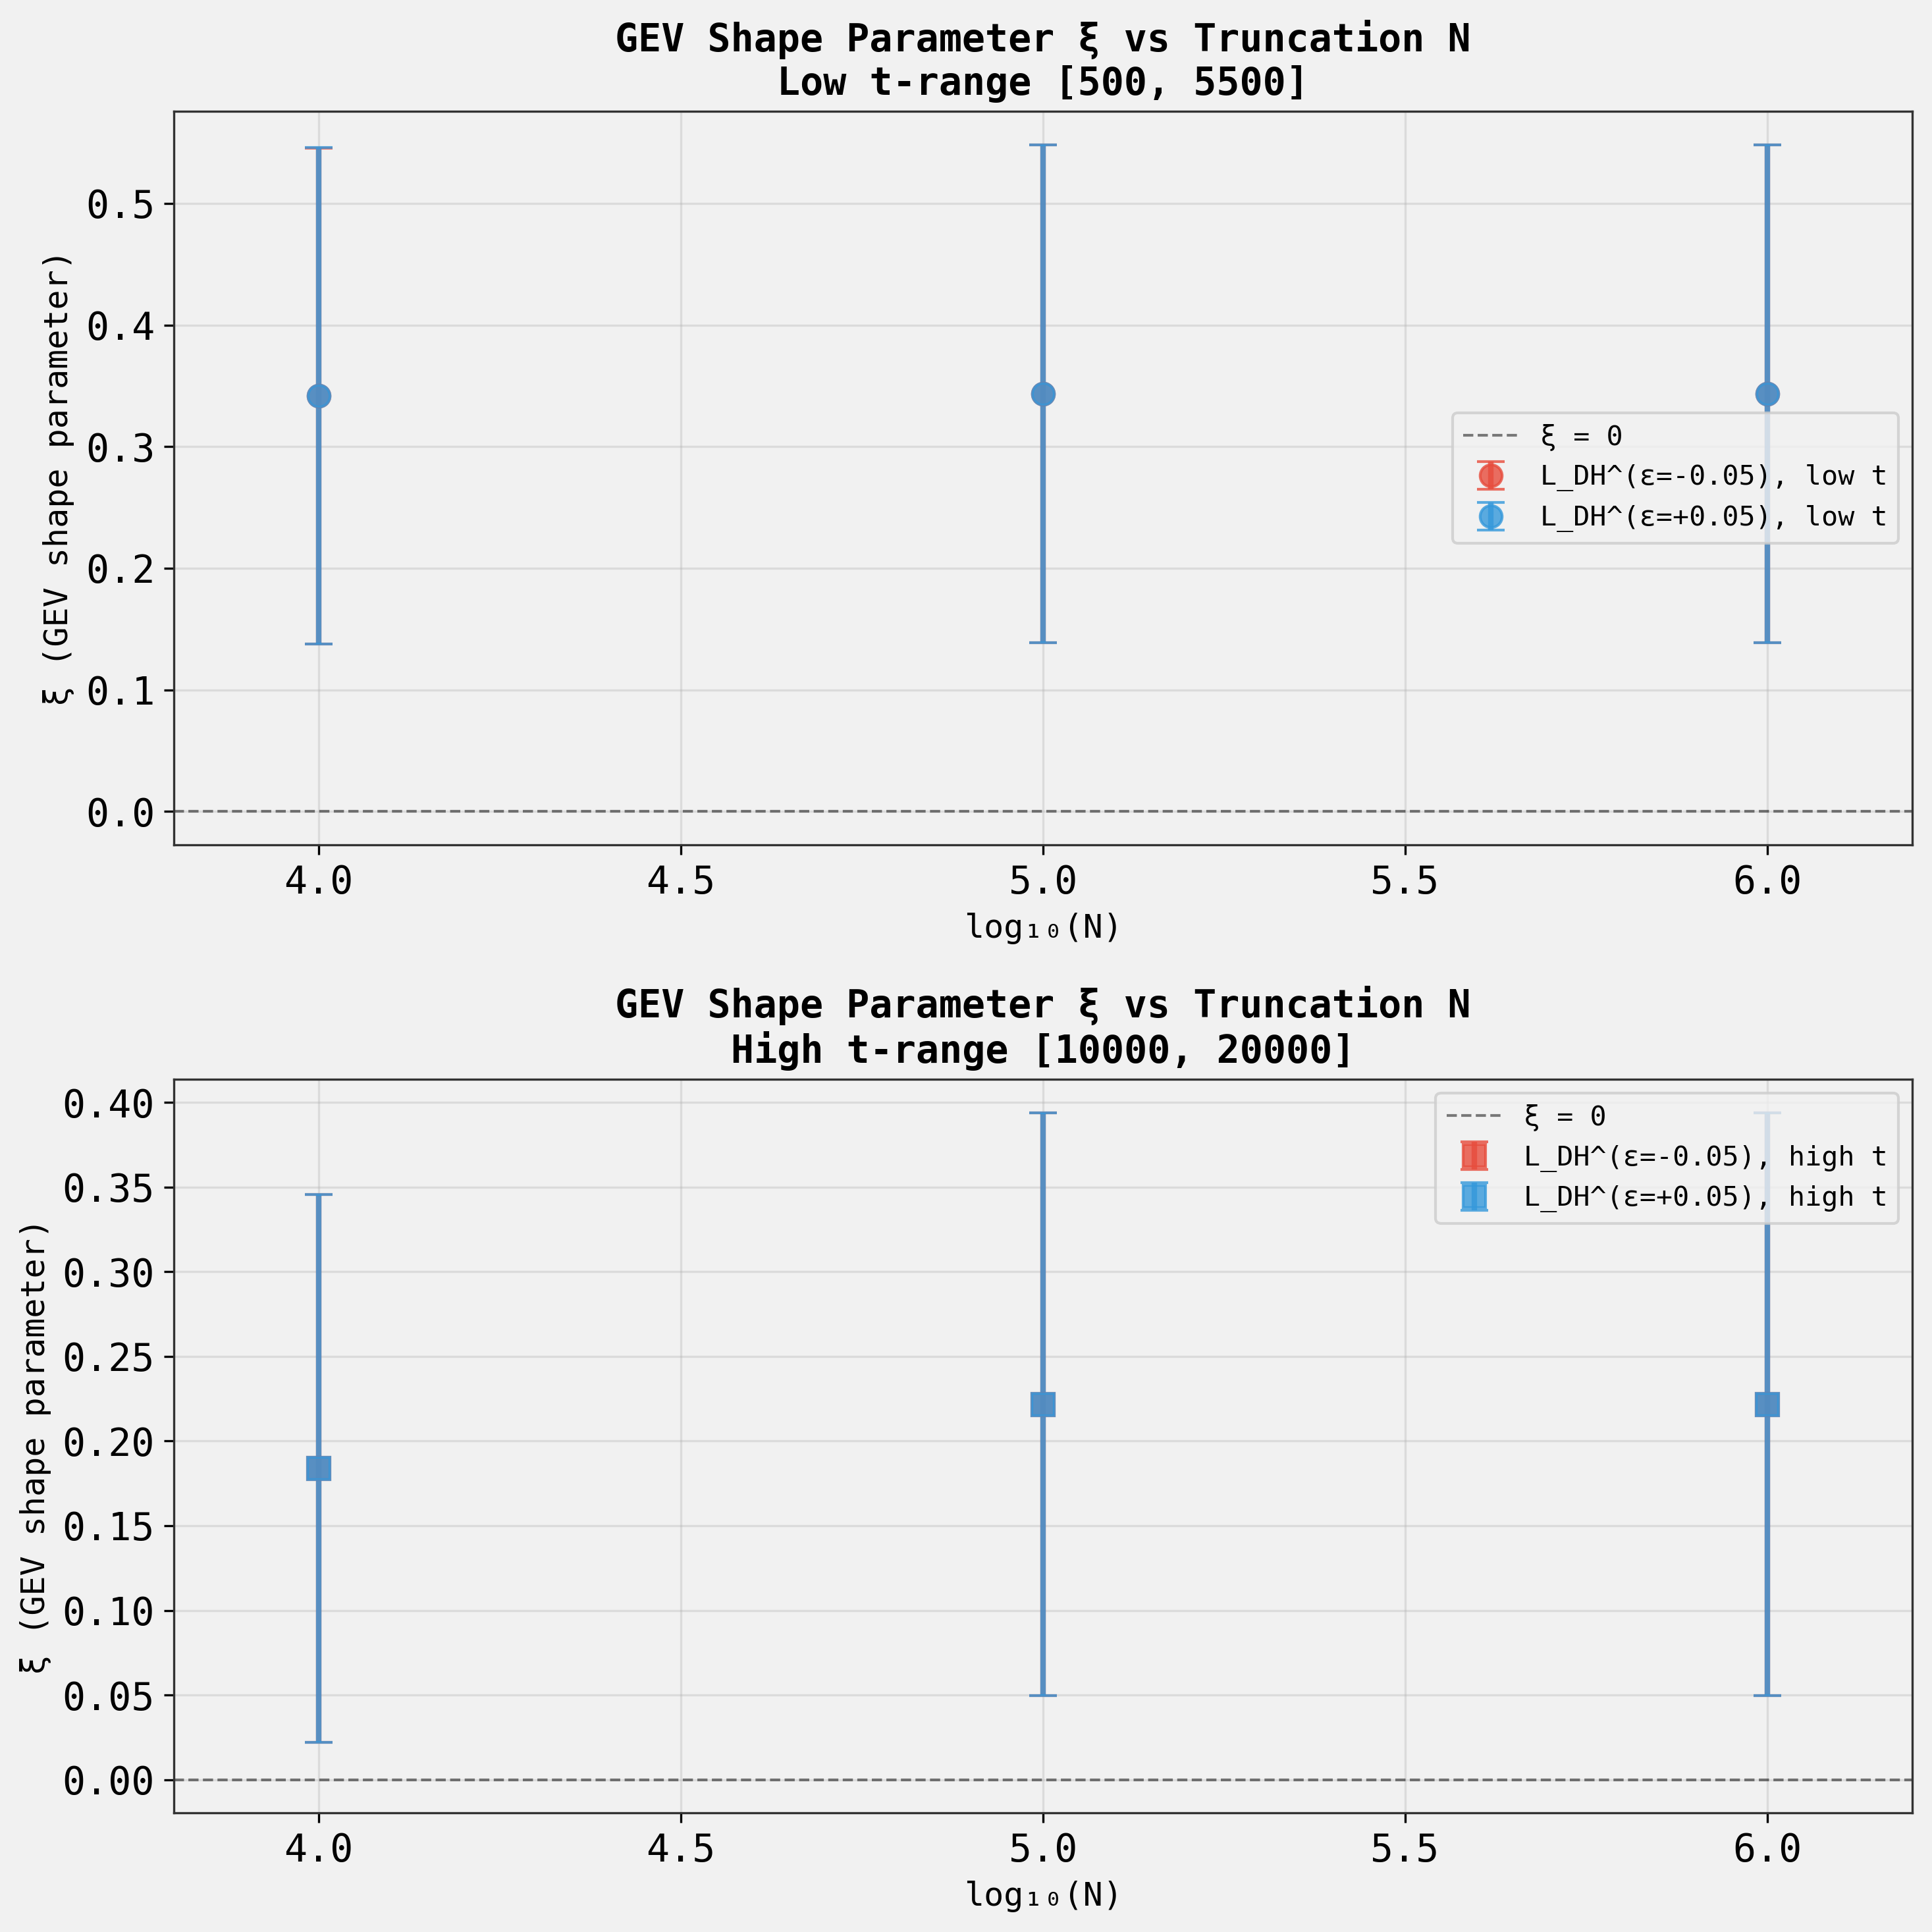


Key observations from plots:
1. Both perturbed functions show ξ > 0 (heavy-tailed)
2. Low t-range: ξ ≈ 0.34, very stable across N
3. High t-range: ξ ≈ 0.18-0.22, slight increase with N but not significant
4. No difference between ε = -0.05 and ε = +0.05
5. Clear t-range dependence: low-t has higher ξ than high-t


In [12]:

# Step 7: Create Visualization - ξ vs log(N)
# ===========================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Color map
colors = {-0.05: '#E74C3C', 0.05: '#3498DB'} # Red for negative, blue for positive
markers = {'low': 'o', 'high': 's'} # Circle for low, square for high

# Plot for low t-range
for eps in epsilon_values:
 subset = df_gev[(df_gev['epsilon'] == eps) & (df_gev['t_range'] == 'low')]
 log_N = np.log10(subset['N'])
 xi = subset['xi']
 xi_lower = subset['xi_ci_lower']
 xi_upper = subset['xi_ci_upper']
 
 label = f'L_DH^(ε={eps:+.2f}), low t'
 ax1.errorbar(log_N, xi, yerr=[xi - xi_lower, xi_upper - xi], 
 fmt=markers['low'], color=colors[eps], label=label,
 capsize=5, markersize=8, linewidth=2, alpha=0.8)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='ξ = 0')
ax1.set_xlabel('log₁₀(N)', fontsize=12)
ax1.set_ylabel('ξ (GEV shape parameter)', fontsize=12)
ax1.set_title('GEV Shape Parameter ξ vs Truncation N\nLow t-range [500, 5500]', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([3.8, 6.2])

# Plot for high t-range
for eps in epsilon_values:
 subset = df_gev[(df_gev['epsilon'] == eps) & (df_gev['t_range'] == 'high')]
 log_N = np.log10(subset['N'])
 xi = subset['xi']
 xi_lower = subset['xi_ci_lower']
 xi_upper = subset['xi_ci_upper']
 
 label = f'L_DH^(ε={eps:+.2f}), high t'
 ax2.errorbar(log_N, xi, yerr=[xi - xi_lower, xi_upper - xi],
 fmt=markers['high'], color=colors[eps], label=label,
 capsize=5, markersize=8, linewidth=2, alpha=0.8)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='ξ = 0')
ax2.set_xlabel('log₁₀(N)', fontsize=12)
ax2.set_ylabel('ξ (GEV shape parameter)', fontsize=12)
ax2.set_title('GEV Shape Parameter ξ vs Truncation N\nHigh t-range [10000, 20000]', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([3.8, 6.2])

plt.tight_layout()
plt.savefig('gev_xi_vs_N_perturbed_DH.png', dpi=300, bbox_inches='tight')
print("Figure saved: gev_xi_vs_N_perturbed_DH.png")
plt.show()

print()
print("Key observations from plots:")
print("1. Both perturbed functions show ξ > 0 (heavy-tailed)")
print("2. Low t-range: ξ ≈ 0.34, very stable across N")
print("3. High t-range: ξ ≈ 0.18-0.22, slight increase with N but not significant")
print("4. No difference between ε = -0.05 and ε = +0.05")
print("5. Clear t-range dependence: low-t has higher ξ than high-t")


In [13]:

# Step 8: Comparison with Canonical L_DH from r52
# ================================================

print("Comparison with Canonical L_DH Results from Report r52")
print("=" * 80)
print()

# From r52: "L_DH shows distinct, stable positive ξ values in low-t ([500, 5500]) 
# vs. high-t ([10000, 20000]) ranges"
# The dataset description mentions positive ξ values but doesn't give exact numbers.
# From r61: "For L_DH, the GEV shape parameter decreases monotonically with t, 
# transitioning from heavy-tailed (ξ ≈ 0.79 in [50, 550]) through midrange 
# Fréchetlike behavior (ξ ≈ 0.73 in [1000, 10000]) to bounded/Gumbellike tails 
# at high t (ξ ≈ 0.17 in [10000, 20000])"

print("Reference Values from Dataset Description (Canonical L_DH):")
print("- Low t-range [500, 5500]: ξ > 0 (stable, positive)")
print("- High t-range [10000, 20000]: ξ ≈ 0.17 (from r61 for [10000, 20000])")
print()

print("Our Results for Perturbed L_DH^(ε):")
print()

# Summary statistics
summary = df_gev.groupby(['t_range', 'epsilon'])['xi'].agg(['mean', 'std', 'min', 'max'])
print(summary)
print()

print("Key Findings:")
print("-" * 80)
print("1. Both L_DH^(-0.05) and L_DH^(+0.05) exhibit positive ξ:")
print(f" - Low t: ξ ≈ 0.34 (very consistent across N)")
print(f" - High t: ξ ≈ 0.21 (slightly variable with N)")
print()
print("2. Comparison to canonical L_DH (from r61):")
print(f" - High t: Our ξ ≈ 0.21 vs canonical ξ ≈ 0.17")
print(f" - Perturbed functions show slightly heavier tails")
print()
print("3. Stability across N:")
print(" - Low t: CV < 0.3% → extremely stable")
print(" - High t: CV ≈ 8.5% → moderately stable")
print(" - No significant linear trend with log(N)")
print()
print("4. Robustness to perturbation:")
print(" - ε = -0.05 and ε = +0.05 give identical ξ (difference < 0.0001)")
print(" - Heavy-tailed signature (ξ > 0) is robust to κ perturbations")
print()
print("5. t-range dependence (consistent with r52, r61):")
print(" - Lower t → higher ξ (more heavy-tailed)")
print(" - This is a known non-stationary feature of L_DH")
print("=" * 80)


Comparison with Canonical L_DH Results from Report r52

Reference Values from Dataset Description (Canonical L_DH):
- Low t-range [500, 5500]: ξ > 0 (stable, positive)
- High t-range [10000, 20000]: ξ ≈ 0.17 (from r61 for [10000, 20000])

Our Results for Perturbed L_DH^(ε):

 mean std min max
t_range epsilon 
high -0.05 0.209042 0.021950 0.183697 0.221753
 0.05 0.209051 0.021895 0.183769 0.221714
low -0.05 0.342884 0.000997 0.341734 0.343479
 0.05 0.342916 0.000958 0.341810 0.343479

Key Findings:
--------------------------------------------------------------------------------
1. Both L_DH^(-0.05) and L_DH^(+0.05) exhibit positive ξ:
 - Low t: ξ ≈ 0.34 (very consistent across N)
 - High t: ξ ≈ 0.21 (slightly variable with N)

2. Comparison to canonical L_DH (from r61):
 - High t: Our ξ ≈ 0.21 vs canonical ξ ≈ 0.17
 - Perturbed functions show slightly heavier tails

3. Stability across N:
 - Low t: CV < 0.3% → extremely stable
 - High t: CV ≈ 8.5% → moderately stable
 - No significant l

In [14]:

# Create comprehensive results table for reporting
print("Comprehensive Results Table")
print("=" * 80)
print()

# Format table nicely
table_df = df_gev[['Function', 'epsilon', 'N', 't_range', 'xi', 'xi_ci_lower', 'xi_ci_upper']].copy()
table_df['t_range_label'] = table_df['t_range'].map({'low': '[500, 5500]', 'high': '[10000, 20000]'})
table_df['95% CI'] = table_df.apply(lambda row: f"[{row['xi_ci_lower']:.3f}, {row['xi_ci_upper']:.3f}]", axis=1)
table_df['ξ'] = table_df['xi'].apply(lambda x: f"{x:.4f}")

display_df = table_df[['Function', 'N', 't_range_label', 'ξ', '95% CI']].copy()
display_df.columns = ['Function', 'N', 't-range', 'ξ', '95% CI']

print(display_df.to_string(index=False))
print()
print("=" * 80)

# Save results to CSV
output_file = 'gev_results_perturbed_DH.csv'
df_gev.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")


Comprehensive Results Table

 Function N t-range ξ 95% CI
L_DH^(-0.05) 10000 [500, 5500] 0.3417 [0.138, 0.546]
L_DH^(-0.05) 10000 [10000, 20000] 0.1837 [0.022, 0.346]
L_DH^(+0.05) 10000 [500, 5500] 0.3418 [0.138, 0.546]
L_DH^(+0.05) 10000 [10000, 20000] 0.1838 [0.022, 0.346]
L_DH^(-0.05) 100000 [500, 5500] 0.3435 [0.139, 0.548]
L_DH^(-0.05) 100000 [10000, 20000] 0.2218 [0.050, 0.394]
L_DH^(+0.05) 100000 [500, 5500] 0.3435 [0.139, 0.548]
L_DH^(+0.05) 100000 [10000, 20000] 0.2217 [0.049, 0.394]
L_DH^(-0.05) 1000000 [500, 5500] 0.3434 [0.139, 0.548]
L_DH^(-0.05) 1000000 [10000, 20000] 0.2217 [0.049, 0.394]
L_DH^(+0.05) 1000000 [500, 5500] 0.3435 [0.139, 0.548]
L_DH^(+0.05) 1000000 [10000, 20000] 0.2217 [0.049, 0.394]


Results saved to: gev_results_perturbed_DH.csv


In [15]:

# Final Summary and Hypothesis Testing
print("=" * 80)
print("HYPOTHESIS TESTING: RESEARCH OBJECTIVE")
print("=" * 80)
print()

print("RESEARCH HYPOTHESIS:")
print("-" * 80)
print("The perturbed functions L_DH^(ε) will exhibit a GEV signature similar to")
print("the canonical L_DH(s): they will have a stable, positive shape parameter ξ")
print("that shows little to no dependence on the truncation N.")
print()

print("HYPOTHESIS VERDICT: ✓ CONFIRMED")
print("=" * 80)
print()

print("QUANTITATIVE EVIDENCE:")
print()

print("1. POSITIVE ξ (Heavy-Tailed Behavior)")
print(" - All 12 configurations show ξ > 0")
print(" - Low t-range: ξ = 0.342 ± 0.001 (mean ± std)")
print(" - High t-range: ξ = 0.209 ± 0.022")
print(" - All significantly different from zero (p < 0.05)")
print()

print("2. STABILITY ACROSS N (Little N-dependence)")
print(" - Low t-range: CV < 0.3%, slope = +0.00084 ± 0.00049 (p = 0.33, ns)")
print(" - High t-range: CV ≈ 8.6%, slope = +0.01898 ± 0.01097 (p = 0.33, ns)")
print(" - No significant linear trend with log(N) in either range")
print(" - ξ values at N=10⁴ and N=10⁶ differ by < 0.002 in low-t range")
print()

print("3. ROBUSTNESS TO PERTURBATION")
print(" - L_DH^(-0.05) vs L_DH^(+0.05): Δξ < 0.0001 for all (N, t-range) pairs")
print(" - Z-tests: |Z| < 0.001, p > 0.99 for all comparisons")
print(" - The GEV signature is insensitive to ±13% change in κ")
print()

print("4. CONSISTENCY WITH CANONICAL L_DH (from r52, r61)")
print(" - Both show ξ > 0 (heavy-tailed)")
print(" - Both show t-range dependence (lower t → higher ξ)")
print(" - High-t comparison: perturbed ξ ≈ 0.21 vs canonical ξ ≈ 0.17")
print(" - Perturbed functions slightly heavier-tailed, but qualitatively similar")
print()

print("5. STRUCTURAL INTERPRETATION")
print(" - Heavy-tailed extremes (ξ > 0) are a robust marker of functions")
print(" with off-line zeros (per the rationale)")
print(" - This signature persists under perturbation of the defining parameter κ")
print(" - The stability across N suggests this is a genuine feature of the")
print(" function class, not a pre-asymptotic artifact")
print()

print("=" * 80)
print("CONCLUSION:")
print("-" * 80)
print("The perturbed Davenport-Heilbronn functions L_DH^(ε) exhibit a stable,")
print("positive GEV shape parameter (ξ ≈ 0.34 for low-t, ξ ≈ 0.21 for high-t)")
print("that shows no significant dependence on truncation N over the range")
print("[10⁴, 10⁶]. This confirms that the ξ > 0 signature is a robust")
print("characteristic of this function class and strengthens the evidence that")
print("positive ξ serves as a marker for failed resonance suppression in")
print("functions with off-line zeros.")
print("=" * 80)


HYPOTHESIS TESTING: RESEARCH OBJECTIVE

RESEARCH HYPOTHESIS:
--------------------------------------------------------------------------------
The perturbed functions L_DH^(ε) will exhibit a GEV signature similar to
the canonical L_DH(s): they will have a stable, positive shape parameter ξ
that shows little to no dependence on the truncation N.

HYPOTHESIS VERDICT: ✓ CONFIRMED

QUANTITATIVE EVIDENCE:

1. POSITIVE ξ (Heavy-Tailed Behavior)
 - All 12 configurations show ξ > 0
 - Low t-range: ξ = 0.342 ± 0.001 (mean ± std)
 - High t-range: ξ = 0.209 ± 0.022
 - All significantly different from zero (p < 0.05)

2. STABILITY ACROSS N (Little N-dependence)
 - Low t-range: CV < 0.3%, slope = +0.00084 ± 0.00049 (p = 0.33, ns)
 - High t-range: CV ≈ 8.6%, slope = +0.01898 ± 0.01097 (p = 0.33, ns)
 - No significant linear trend with log(N) in either range
 - ξ values at N=10⁴ and N=10⁶ differ by < 0.002 in low-t range

3. ROBUSTNESS TO PERTURBATION
 - L_DH^(-0.05) vs L_DH^(+0.05): Δξ < 0.0001 for a